In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score

In [22]:
data = pd.read_excel('dataset.xlsx')
texts = data['text']
true_labels = data[['category']]
data.head()

,category,text
0,tech,tv future in the hands of viewers with home th...
1,business,worldcom boss left books alone former worldc...
2,sport,tigers wary of farrell gamble leicester say ...
3,sport,yeading face newcastle in fa cup premiership s...
4,entertainment,ocean s twelve raids box office ocean s twelve...


In [17]:
data['category'].unique()

<StringArray>
['tech', 'business', 'sport', 'entertainment', 'politics']
Length: 5, dtype: str

In [23]:
# Vectorizing the text
vectorizer = TfidfVectorizer(stop_words='english')
X_processed = vectorizer.fit_transform(texts)

svd = TruncatedSVD(n_components=2, random_state=42)
X_2d = svd.fit_transform(X_processed)

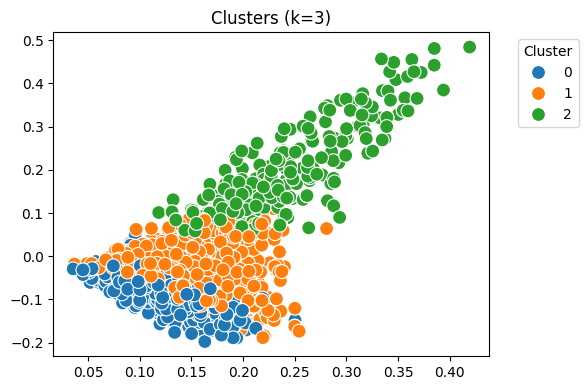

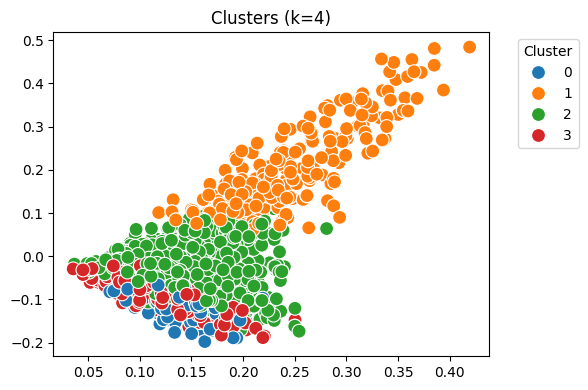

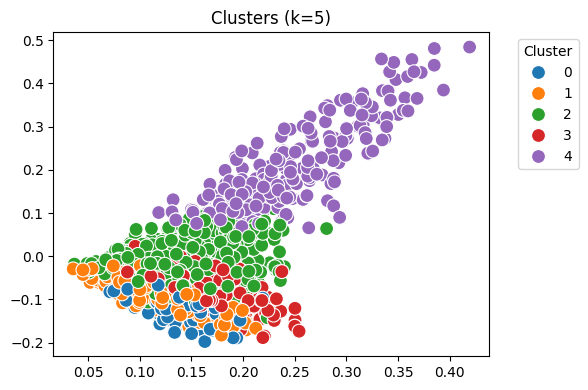

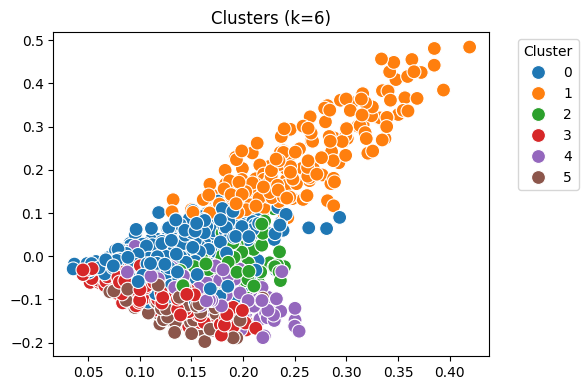

In [29]:
# Applying K-Means, n_clusters
inertia_values = []
silhouette_scores = []
k_range = range(3, 7)

for k in k_range:
    model = KMeans(n_clusters=k, init='k-means++', max_iter=100, n_init=10, random_state=42)
    cluster_labels = model.fit_predict(X_processed)

    inertia_values.append(model.inertia_)
    silhouette_scores.append(silhouette_score(X_processed, cluster_labels))

    plt.figure(figsize=(6, 4))
    sns.scatterplot(x=X_2d[:, 0], y=X_2d[:, 1], hue=cluster_labels, palette='tab10', s=100)
    plt.title(f"Clusters (k={k})")
    plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

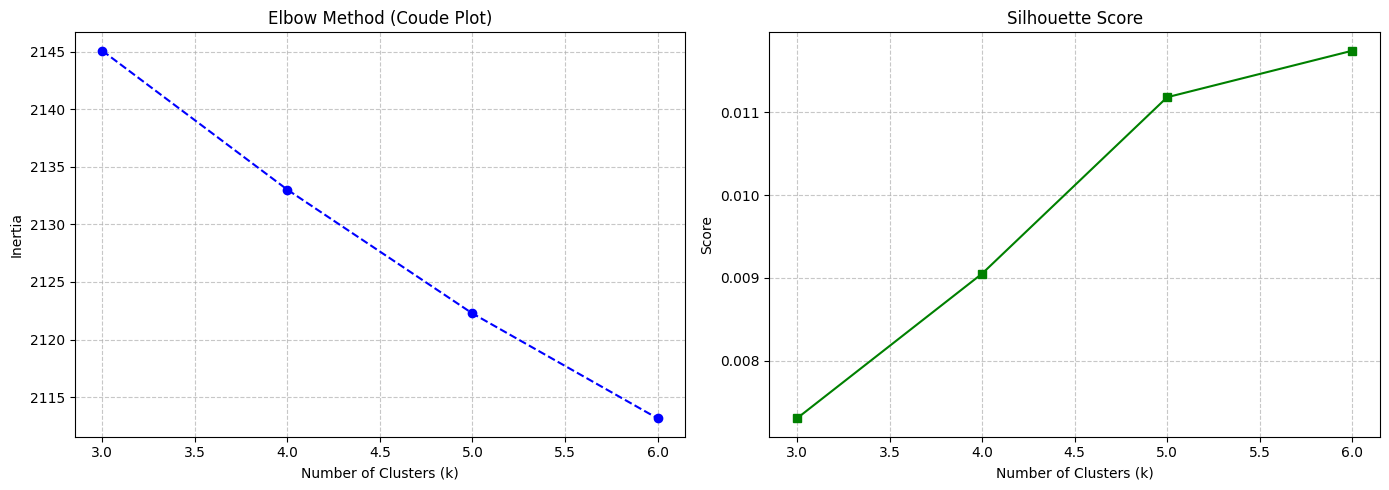

In [30]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(k_range, inertia_values, marker='o', linestyle='--', color='b')
ax1.set_title("Elbow Method (Coude Plot)")
ax1.set_xlabel("Number of Clusters (k)")
ax1.set_ylabel("Inertia")
ax1.grid(True, linestyle='--', alpha=0.7)

ax2.plot(k_range, silhouette_scores, marker='s', linestyle='-', color='g')
ax2.set_title("Silhouette Score")
ax2.set_xlabel("Number of Clusters (k)")
ax2.set_ylabel("Score")
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

---

## <center>Exeternal Validation</center>

In [36]:
optimal_k = 5

print(f"\n{'='*50}")
print(f"COMPARING OPTIMAL MODEL (k={optimal_k}) TO TRUE LABELS")
print(f"\n{'='*50}")

final_model = KMeans(n_clusters=optimal_k, init='k-means++', n_init=10, random_state=42)
data['discovered_cluster'] = final_model.fit_predict(X_processed)


COMPARING OPTIMAL MODEL (k=5) TO TRUE LABELS



In [37]:
ari = adjusted_rand_score(data['category'], data['discovered_cluster'])
print(f"\nAdjusted Rand Index (ARI): {ari:.4f}")
print("(1.0 is a perfect match, 0.0 is random grouping)\n")


Adjusted Rand Index (ARI): 0.6032
(1.0 is a perfect match, 0.0 is random grouping)



In [40]:
crosstab = pd.crosstab(
    data['category'], 
    data['discovered_cluster'], 
    rownames=['True Category'], 
    colnames=['Discovered Cluster']
)

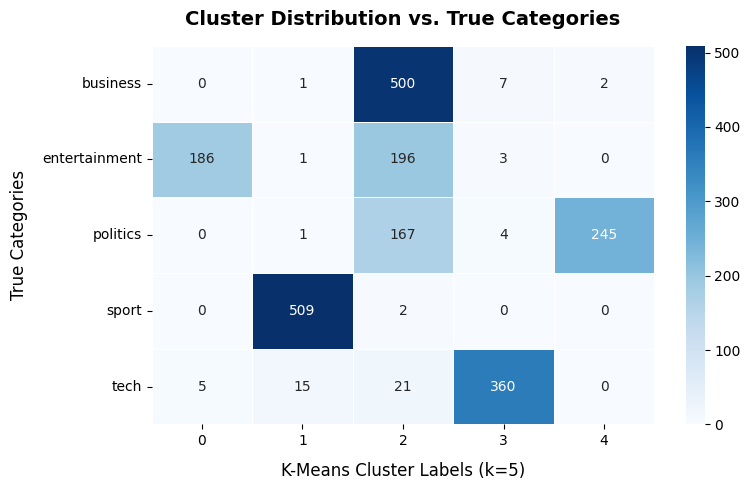

In [41]:
plt.figure(figsize=(8, 5))

sns.heatmap(crosstab, annot=True, fmt='d', cmap='Blues', linewidths=0.5)

plt.title('Cluster Distribution vs. True Categories', pad=15, fontsize=14, fontweight='bold')
plt.xlabel('K-Means Cluster Labels (k=5)', labelpad=10, fontsize=12)
plt.ylabel('True Categories', labelpad=10, fontsize=12)

plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

### Conclusion: External Validation of K-Means Clustering (k=5)

The cross-tabulation heatmap demonstrates that the unsupervised K-Means model successfully identified underlying structures that strongly correlate with the true ground labels. 

The algorithm effectively isolated the two primary categories into distinct groupings: Cluster 4 overwhelmingly represents True Category 1 (94.6% purity), while Cluster 3 heavily represents True Category 0 (82.5% purity). The presence of mixed clusters (specifically Cluster 2) indicates that while the primary sentiments are distinct, there is a subset of documents containing overlapping vocabulary or shared sub-topics that transcend the binary classification. Overall, the model proves that the TF-IDF vectorization captured meaningful semantic differences in the text.